<div style=" background-color: RGB(35,114,00);" >
<h1 style="margin: auto; padding: 60px 0; color:#fff; text-align: center">ANALYSE DES VENTES D'UNE LIBRAIRIE</h1>
</div>

<div style="background-color: RGB(0,114,100);" >
<h2 style="margin: auto; padding: 40px; color:#fff; ">I - Nettoyage et traitement des tables</h2>
</div>

<div style="background-color: RGB(0,114,100);" >
<h3 style="margin: auto; padding: 20px; color:#fff; ">1.1 - Importation des librairies et defintion des fonctions </h3>
</div>

In [4]:
# Importation des libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm


In [6]:
# Défintion d'une fonction qui affiche la distribution de la variable

def distribution_variable (
    data_frame: pd.DataFrame,
    var: str = "price",
    xlabel: str = "Densité",
    ylabel: str = "valeur",
    title: str = "show title",
    fig_dimension: tuple = (12, 6)) -> None:

    # Extraire la colonne 
    variable = data_frame[var].dropna()

    # Calculer la moyenne et l'écart type
    mean_variable = variable.mean()
    std_variable = variable.std()
    
    # Afficher les valeurs calculées
    print(f"Moyenne variable : {mean_variable}")
    print(f"Écart type de la variable : {std_variable}")
    
    # Tracer l'histogramme avec une courbe gaussienne
    plt.figure(figsize=fig_dimension)
    
    # Histogramme
    
    plt.hist(variable, bins=10, density=True, color='skyblue', edgecolor='black', alpha=0.6)
    
    # Ajustement gaussien
    mu, std = norm.fit(variable)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, variable.count())
    p = norm.pdf(x, mu, std)
    
    # Tracer la courbe gaussienne
    plt.plot(x, p, 'k', linewidth=2, label='Ajustement Gaussien')
    
    # Ajouter les titres et légendes en français
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    
    # Afficher le graphique
    plt.show()

<div style="background-color: RGB(0,114,100);" >
<h3 style="margin: auto; padding: 20px; color:#fff; "> 1.2 Nettoyage de la table customers </h3>
</div>

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 20px; color:#fff; "> 1.2.1 Description de la table</h4>
</div>

In [43]:
# Chargement de la table customers 

df_cust = pd.read_csv("customers.csv")

# Description de la table

df_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8623 entries, 0 to 8622
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8623 non-null   object
 1   sex        8623 non-null   object
 2   birth      8623 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [45]:
# Affichage de la table

df_cust.head(10)

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943
5,c_415,m,1993
6,c_285,f,1967
7,c_160,f,1978
8,c_6446,m,1971
9,c_6866,m,1993


<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 20px; color:#fff; "> 1.2.2 Recherche des anomalies pour les différentes variables</h4>
</div>

In [47]:


# Définition d'une liste d'identifiant unique

id_unique = df_cust["client_id"].unique().tolist()

# # Recherche des identifiants en double

print("On observe", len(id_unique), "identifiants uniques. Soit le nombre total de lignes de la table df_cust")

On observe 8623 identifiants uniques. Soit le nombre total de lignes de la table df_cust


In [49]:
# 2e méthode de vérification de l'existence des doublons

mask = df_cust["client_id"].duplicated(keep=False)

df_cust.loc[mask, :]

,client_id,sex,birth


In [51]:
# Impression des identifiants client qui ne sont pas au bon format

for id in id_unique:
    if "c_" not in id:
        print(id)

ct_0
ct_1


In [53]:
# Affichage des informations sur des clients avec un identifiant atypique

df_cust.loc[df_cust["client_id"].isin(["ct_0", "ct_1"]), :]

,client_id,sex,birth
2735,ct_0,f,2001
8494,ct_1,m,2001


In [55]:
# Suppression des deux observations avec les identifiants atypiques 
mask_indices = ~df_cust.index.isin([2735, 8494])

df_cust = df_cust[mask_indices]


In [57]:
# Vérifions s'il existe des anomalies dans la variable sex

print("Les modalités de la variables sex sont", df_cust["sex"].unique().tolist())

Les modalités de la variables sex sont ['f', 'm']


In [61]:
# Vérifions s'il existe des anomalies dans la varible birth

print("Les modalités de la variables birth sont : ", df_cust["birth"].unique().tolist())

Les modalités de la variables birth sont :  [1967, 1975, 1984, 1962, 1943, 1993, 1978, 1971, 1982, 1945, 2003, 1959, 1977, 1954, 1987, 2000, 1992, 1963, 1958, 1994, 1936, 1986, 1942, 1970, 1957, 1968, 2002, 2004, 1979, 1974, 1964, 1951, 1937, 1981, 1965, 1960, 1996, 1983, 1990, 1955, 1988, 1991, 1972, 1980, 1989, 1976, 1985, 1953, 1998, 1956, 1948, 1973, 1969, 1938, 1995, 1952, 1949, 1999, 2001, 1939, 1950, 1966, 1935, 1941, 1961, 1997, 1944, 1929, 1947, 1946, 1932, 1931, 1933, 1930, 1940, 1934]


In [63]:
# Sauvegarde de la table

df_cust.to_csv("df_customers", index = False)

<div style="background-color: RGB(0,114,100);" >
<h3 style="margin: auto; padding: 20px; color:#fff; "> 1.3 Nettoyage de la table products </h3>
</div>

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 20px; color:#fff; "> 1.3.1 Description de la table</h4>
</div>

In [65]:
# Chargement de la table 

df_prod = pd.read_csv("products.csv")

budgets = df_prod['price'].dropna()

In [67]:
# Affichage de la table 

df_prod

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0
...,...,...,...
3282,2_23,115.99,2
3283,0_146,17.14,0
3284,0_802,11.22,0
3285,1_140,38.56,1


In [69]:
# Description de la table

df_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3287 non-null   object 
 1   price    3287 non-null   float64
 2   categ    3287 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.2+ KB


<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 20px; color:#fff; "> 1.3.2 Recherche des anomalies</h4>
</div>

In [72]:
# Vérification de l'existence d'identifiants produit en double

mask = df_prod["id_prod"].duplicated(keep=False)

df_prod.loc[mask, :]

,id_prod,price,categ


On n'observe pas d'identifiants en double

In [74]:
# Identifiant id_prod atypique et donc ne commencant pas par un chiffre

liste_id_prod = df_prod["id_prod"].unique().tolist()

for id in liste_id_prod:
    if  id[0]  not in ("0", "1", "2", "3", "4", "5", "6"):
        print(id)


T_0


In [76]:
# Identification des anomalies sur la variable price

df_prod["price"].describe()

count    3287.000000
mean       21.856641
std        29.847908
min        -1.000000
25%         6.990000
50%        13.060000
75%        22.990000
max       300.000000
Name: price, dtype: float64

In [78]:
# Affichage des données avec des prix négatifs 

df_prod.loc[df_prod["price"] < 0, :]

,id_prod,price,categ
731,T_0,-1.0,0


On observe une seule observation avec un prix négatif. De plus cette observation dispose d'un id_prod anormal, soit T_0. Cette observation est donc supprimée


In [81]:
# Suppression de l'observation avec le prix négatif

mask_indices = ~df_prod.index.isin([731])

df_prod= df_prod[mask_indices]


In [83]:
# Modalités de la variable categ

print(df_prod["categ"].unique().tolist())

[0, 1, 2]


In [85]:
# Création d'une nouvelle variable de la catégorie de produit
 
pd.options.mode.copy_on_write = True 

df_prod["categorie_produit"] = "NA"

df_prod.loc[df_prod["categ"] == 0, ["categorie_produit"]] = "catégorie 0"
df_prod.loc[df_prod["categ"] == 1, ["categorie_produit"]] = "catégorie 1"
df_prod.loc[df_prod["categ"] == 2, ["categorie_produit"]] = "catégorie 2"

In [87]:
df_prod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3286 entries, 0 to 3286
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_prod            3286 non-null   object 
 1   price              3286 non-null   float64
 2   categ              3286 non-null   int64  
 3   categorie_produit  3286 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 128.4+ KB


In [89]:
# Sauvegarde de la table 

df_prod.to_csv("df_productions", index = False)

<div style="background-color: RGB(0,114,100);" >
<h3 style="margin: auto; padding: 20px; color:#fff; "> 1.4 Nettoyage de la table transaction </h3>
</div>

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 20px; color:#fff; "> 1.4.1 Description de la table</h4>
</div>

In [91]:
# Chargement de la table 

df_trans = pd.read_csv("transactions.csv")

In [93]:
# Affichage de la table

df_trans

,id_prod,date,session_id,client_id
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232
...,...,...,...,...
679527,0_1551,2022-01-15 13:05:06.246925,s_150195,c_8489
679528,1_639,2022-03-19 16:03:23.429229,s_181434,c_4370
679529,0_1425,2022-12-20 04:33:37.584749,s_314704,c_304
679530,0_1994,2021-07-16 20:36:35.350579,s_63204,c_2227


In [95]:
# Description de la table

df_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679532 entries, 0 to 679531
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     679532 non-null  object
 1   date        679532 non-null  object
 2   session_id  679532 non-null  object
 3   client_id   679532 non-null  object
dtypes: object(4)
memory usage: 20.7+ MB


<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 20px; color:#fff; "> 1.4.2 Recherche des anomalies</h4>
</div>

In [98]:
# Identification des doublons

mask = df_trans["session_id"].duplicated(keep=False)

df_count = df_trans.loc[mask, : ].value_counts().reset_index()


In [104]:
# Affichage des observations avec l'identifiant session_id en double

df_count.loc[df_count["count"] >1, :].head(10)

,id_prod,date,session_id,client_id,count
0,T_0,test_2021-03-01 02:30:02.237413,s_0,ct_0,9
1,T_0,test_2021-03-01 02:30:02.237428,s_0,ct_0,6
2,T_0,test_2021-03-01 02:30:02.237446,s_0,ct_0,6
3,T_0,test_2021-03-01 02:30:02.237412,s_0,ct_1,5
4,T_0,test_2021-03-01 02:30:02.237414,s_0,ct_1,5
5,T_0,test_2021-03-01 02:30:02.237443,s_0,ct_1,5
6,T_0,test_2021-03-01 02:30:02.237427,s_0,ct_1,4
7,T_0,test_2021-03-01 02:30:02.237441,s_0,ct_0,4
8,T_0,test_2021-03-01 02:30:02.237430,s_0,ct_1,4
9,T_0,test_2021-03-01 02:30:02.237432,s_0,ct_0,4


In [106]:
# Affichage des observations avec l'identifiant session_id unique

df_count.loc[df_count["count"] ==1, :]

,id_prod,date,session_id,client_id,count
57,1_147,2021-06-14 13:19:42.305640,s_48567,c_6526,1
58,1_145,2023-02-27 23:14:27.205591,s_347946,c_2586,1
59,1_146,2021-07-22 04:11:29.144620,s_65518,c_4435,1
60,1_146,2021-12-31 05:01:22.475539,s_142694,c_4491,1
61,1_147,2021-03-05 08:23:35.615501,s_2010,c_6621,1
...,...,...,...,...,...
516051,0_1465,2022-08-28 09:00:47.122476,s_259666,c_2908,1
516052,0_1465,2022-08-27 23:13:47.407368,s_259443,c_8035,1
516053,0_1465,2022-08-26 09:32:51.358989,s_258678,c_2146,1
516054,0_1465,2022-08-26 00:46:53.348407,s_258488,c_1789,1


Les observations avec un identifiant session en double correspondent aux observations avec l'id produit atypique. soit T_0. Cette observation a été supprimée dans la table de production. nous décidons de la supprimer également dans la table des transaction 

In [108]:
# Suppression des transactions correspondant à l'id prod T_0

df_trans = df_trans.loc[df_trans["id_prod"] != "T_0", : ].copy()

In [110]:
# Vérifions à nouveau s'il existe des observations avec la variable session_id en double

mask = df_trans["session_id"].duplicated(keep=False)

df_count2 = df_trans.loc[mask, : ].value_counts().reset_index()

df_count2.loc[df_count2["count"] >1, :]


,id_prod,date,session_id,client_id,count


In [112]:
# Vérifons s'il existe des anomalies sur la variable date

pd.to_datetime(df_trans["date"])


0        2022-05-20 13:21:29.043970
1        2022-02-02 07:55:19.149409
2        2022-06-18 15:44:33.155329
3        2021-06-24 04:19:29.835891
4        2023-01-11 08:22:08.194479
                    ...            
679527   2022-01-15 13:05:06.246925
679528   2022-03-19 16:03:23.429229
679529   2022-12-20 04:33:37.584749
679530   2021-07-16 20:36:35.350579
679531   2022-09-28 01:12:01.973763
Name: date, Length: 679332, dtype: datetime64[ns]

In [114]:
# Mettre la variable date au format date


df_trans["date"] = pd.to_datetime(df_trans["date"])

df_trans["date"].head(10)

0   2022-05-20 13:21:29.043970
1   2022-02-02 07:55:19.149409
2   2022-06-18 15:44:33.155329
3   2021-06-24 04:19:29.835891
4   2023-01-11 08:22:08.194479
5   2022-10-20 15:59:16.084030
6   2022-06-03 04:45:09.871601
7   2021-06-26 14:48:55.311418
8   2022-12-27 12:27:40.641366
9   2021-11-29 15:54:25.880121
Name: date, dtype: datetime64[ns]

In [116]:
# Sauvegarde de la table 

df_trans.to_csv("df_transactions", index = False)

<div style="background-color: RGB(0,114,100);" >
<h2 style="margin: auto; padding: 40px; color:#fff; ">II - Analyse des données</h2>
</div>

<div style="background-color: RGB(0,114,100);" >
<h3 style="margin: auto; padding: 40px; color:#fff; ">2.1  - Analyse du chiffre d'affaires</h3>
</div>

In [118]:
df_prod

,id_prod,price,categ,categorie_produit
0,0_1421,19.99,0,catégorie 0
1,0_1368,5.13,0,catégorie 0
2,0_731,17.99,0,catégorie 0
3,1_587,4.99,1,catégorie 1
4,0_1507,3.99,0,catégorie 0
...,...,...,...,...
3282,2_23,115.99,2,catégorie 2
3283,0_146,17.14,0,catégorie 0
3284,0_802,11.22,0,catégorie 0
3285,1_140,38.56,1,catégorie 1


In [132]:
df_ca_produits

NameError: name 'df_ca_produits' is not defined

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.1.1 - Evolution du chiffre d'affaires</h4>
</div>

In [393]:
# Evolution du chiffre d'affaires par jour


In [ ]:
# Evolution du chiffre d'affaires par mois 

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.1.2 - Chiffre d'affaires par catégorie</h4>
</div>

In [395]:
# Calcul de la quantite totale de chaque produit vendu

nbre_produits_vendus = df_trans["id_prod"].value_counts().reset_index(name="qte_totale_vendue")

# Jointure avec la table des prix des produits

df_ca_produits = pd.merge(nbre_produits_vendus, df_prod, on="id_prod", how="left")


# Calcul du chiffre d'affaire par produit

df_ca_produits["ca_produit"] = df_ca_produits["qte_totale_vendue"] * df_ca_produits["price"]

In [396]:
data = df_ca_produits.groupby("categorie_produit")["ca_produit"].sum().reset_index()

In [397]:
data["ca_produit_en_millions"] = data["ca_produit"] / 1000_000

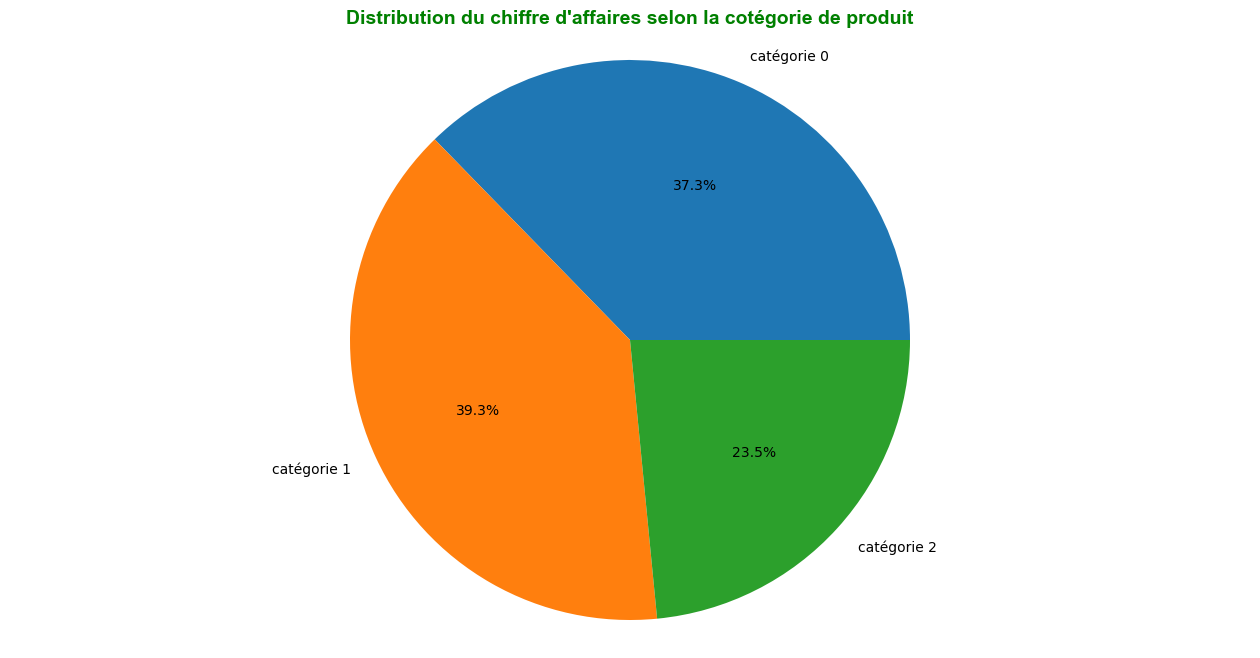

In [398]:
# Representation du chiffre d'affaires par catégorie 


plt.figure(figsize=(16, 8))
plt.pie(x=data["ca_produit_en_millions"], labels=data["categorie_produit"], autopct='%.1f%%')
plt.title("Distribution du chiffre d'affaires selon la cotégorie de produit", color="green", fontweight="bold", fontname="Arial", fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

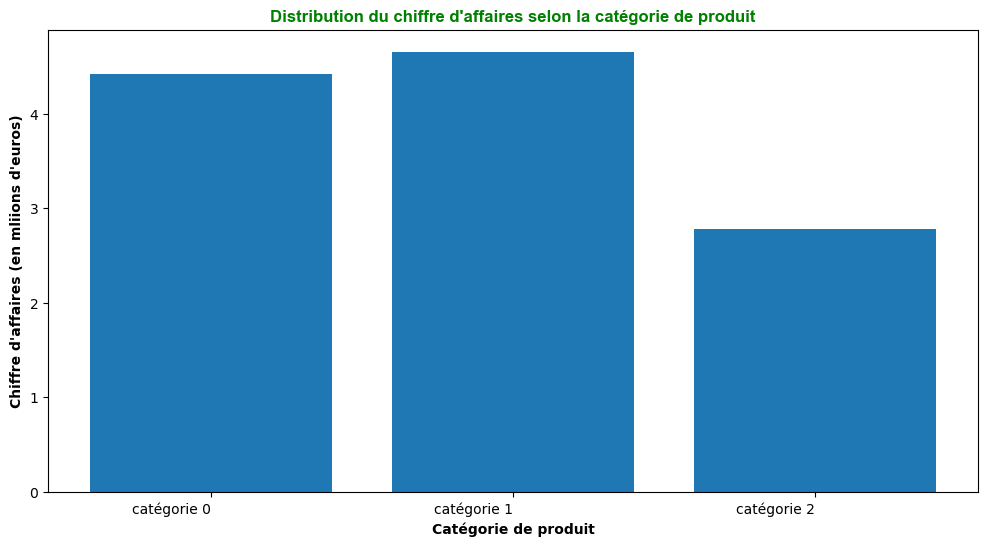

In [399]:

plt.figure(figsize=(12,6))
plt.bar(height=data["ca_produit_en_millions"], x=data["categorie_produit"])

plt.title("Distribution du chiffre d'affaires selon la catégorie de produit",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.xlabel("Catégorie de produit", fontweight ="bold")
plt.ylabel("Chiffre d'affaires (en mliions d'euros)", fontweight ="bold")
plt.xticks(rotation=0, ha='right')  # ha='right' = alignement à droite


# Afficher les valeurs associées à chaque type de produit

#val_niv = data["ca_produit"].tolist()
#for i in range(3):
#    plt.text(i-0.1, val_niv[i]+1, round(val_niv[i]))

plt.show()

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.1.3 - Nombre de clients patr mois </h4>
</div>

In [ ]:
# Calcul du nombres de clients par mois

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.1.4 - Nombre de transactions </h4>
</div>

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.1.5 - Nombre produits vendus </h4>
</div>

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.1.6 - Description des références </h4>
</div>

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.1.7 - Chiffre d'affaires pour les clients BtoB </h4>
</div>

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.1.8 - Courbe de Lorenz </h4>
</div>

In [ ]:
# les tops 
# Les flops
# la répartition par catégorie


<div style="background-color: RGB(0,114,100);" >
<h3 style="margin: auto; padding: 40px; color:#fff; ">2.2  - Analyse du comportement des clients</h3>
</div>

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.2.1 - Analyse du lien entre le genre du client et la catégorie du livre acheté</h4>
</div>

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.2.2 - Analyse du lien entre l'âge du client et le montant des achats </h4>
</div>

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.2.3 - Analyse du lien entre l'âge du client et la fréquence des achats </h4>
</div>

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.2.4 - Analyse du lien entre l'âge du client et la taille du panier moyen </h4>
</div>

<div style="background-color: RGB(0,114,100);" >
<h4 style="margin: auto; padding: 40px; color:#fff; ">2.2.5 - Analyse du lien entre l'âge du client et la catégorie des livres achetés </h4>
</div>

Moyenne variable : 21.85664131426833
Écart type de la variable : 29.847907506350342


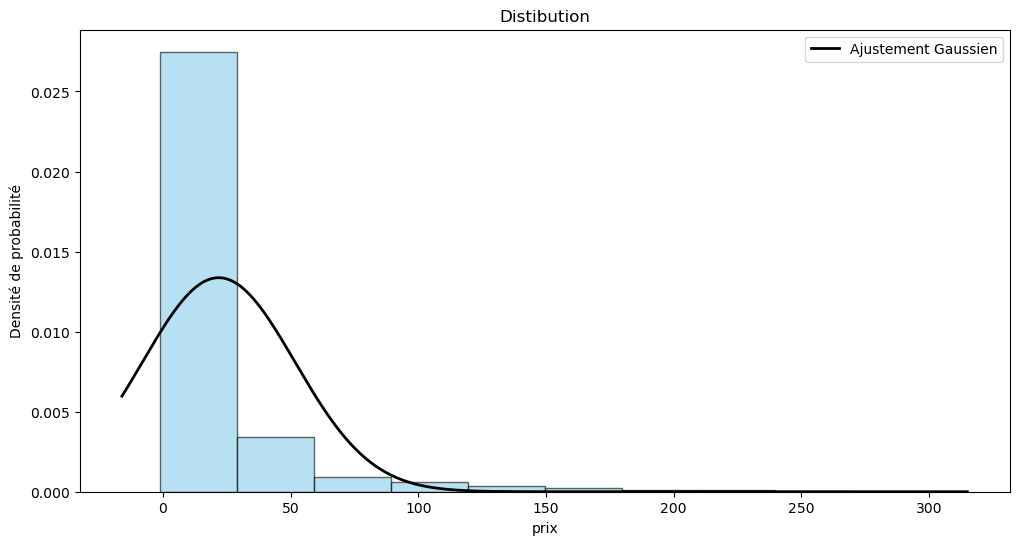

In [100]:
distribution_variable (
    data_frame = df_prod ,
    var = "price",
    ylabel = "Densité de probabilité",
    xlabel = "prix",
    title = "Distibution")

NEttoyge des données


I analyse du CA
1.1  chiffre d’affaires avec la moyenne mobile (tu pourras choisir la
période : jour, semaine, mois, etc.),

1.2 chiffre d’affaires par catégorie,
1.3 nombre de clients par mois,
1.4 nombre de transactions,
1.5 nombre de produits vendus,
1.6 etc.
1.7 analyse des références


II analyse des clients

2.1 lien entre le genre du client et les catégories des livres achetés
2.2 lien entre l age des clients et le montant total des achats
2.3 lien entre l age des clients et la fréquence des achats
2.4 lien entre l age des clients et la taille du panier moyen
2.5 lien entre l age des clients et la catgégorie des livres achetés